In [1]:
import pandas as pd 

In [2]:
df = pd.read_csv(r"C:\Users\Admin\Documents\Machine Learning\Mall_Customers.csv")
df.head(3)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6


In [3]:
df.drop("CustomerID", axis=1, inplace=True)

<Axes: ylabel='Spending Score (1-100)'>

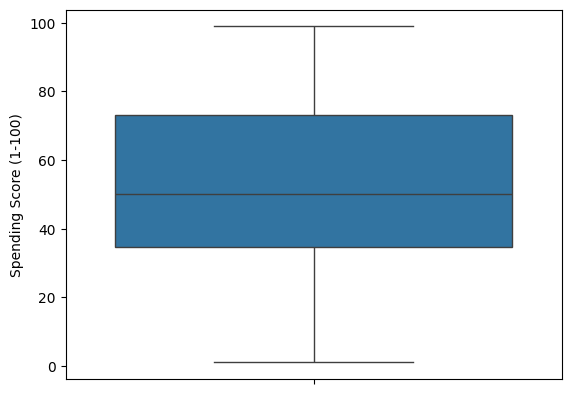

In [6]:
import seaborn as sns 
sns.boxplot(data=df, y="Spending Score (1-100)")

In [7]:
df["Annual Income (k$)"].describe()

count    200.000000
mean      60.560000
std       26.264721
min       15.000000
25%       41.500000
50%       61.500000
75%       78.000000
max      137.000000
Name: Annual Income (k$), dtype: float64

In [8]:
q1 = 41.5
q3 = 78.0 
IQR = q3 - q1  

In [9]:
ub = q3 + 1.5*IQR
lb = q1 - 1.5*IQR

In [10]:
df = df[(df["Annual Income (k$)"]>lb)&(df["Annual Income (k$)"]<ub)]

<Axes: ylabel='Annual Income (k$)'>

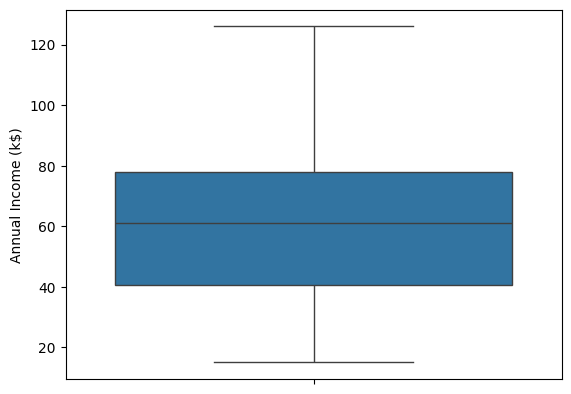

In [11]:
sns.boxplot(data=df, y="Annual Income (k$)")

In [12]:
df.describe()

,Age,Annual Income (k$),Spending Score (1-100)
count,198.000000,198.000000,198.000000
mean,38.929293,59.787879,50.196970
std,14.016852,25.237259,25.746846
min,18.000000,15.000000,1.000000
25%,28.250000,40.500000,35.000000
50%,36.000000,61.000000,50.000000
75%,49.000000,77.750000,72.750000
max,70.000000,126.000000,99.000000


In [20]:
df["Genre"].unique()

<ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str

In [23]:
df.replace({'Male':1, 'Female':0}, inplace=True)

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40
...,...,...,...,...
193,0,38,113,91
194,0,47,120,16
195,0,35,120,79
196,0,45,126,28


In [24]:
x = df[["Genre", "Age", "Annual Income (k$)", "Spending Score (1-100)"]]

In [25]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [27]:
df["Annual Income (k$)"] = scaler.fit_transform(df[["Annual Income (k$)"]])
df["Spending Score (1-100)"] = scaler.fit_transform(df[["Spending Score (1-100)"]])

In [46]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=3)

In [47]:
model.fit(x)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [48]:
model.fit_transform(x)

array([[ 83.53030369,  37.71435793,  76.63641594],
       [ 71.19983776,  46.85523924,  96.25054429],
       [103.65908726,  55.91921101,  73.73220155],
       [ 70.08337931,  42.79311677,  92.55592746],
       [ 80.18003461,  30.34970348,  72.53520845],
       [ 69.32529008,  41.93150179,  91.3720031 ],
       [101.56017689,  51.31845843,  69.05211295],
       [ 68.95113489,  54.17968101, 102.78594777],
       [107.78461004,  58.19429565,  72.34436962],
       [ 67.03570182,  35.0865195 ,  86.03192198],
       [100.96844766,  51.26773765,  71.83110619],
       [ 68.37009236,  55.48901991, 104.54782808],
       [ 96.91556853,  45.92472222,  68.00977457],
       [ 65.99598116,  39.85429292,  89.39332903],
       [ 95.11154699,  44.17287304,  65.99246255],
       [ 66.16801623,  42.0777304 ,  91.09902382],
       [ 79.66869591,  28.00999439,  66.92294665],
       [ 67.42087801,  34.80069311,  82.74712197],
       [ 84.02785285,  31.90647584,  64.51129991],
       [ 64.24948128,  52.88150

In [49]:
df["output"] = model.predict(x)

In [50]:
df.head()

,Genre,Age,Annual Income (k$),Spending Score (1-100),output
0,1,19,0.000000,0.387755,1
1,1,21,0.000000,0.816327,1
2,0,20,0.009009,0.051020,1
3,0,23,0.009009,0.775510,1
4,0,31,0.018018,0.397959,1


In [51]:
df["output"].unique()

array([1, 0, 2], dtype=int32)

In [67]:
df0 = df[df["output"]==0]
df1 = df[df["output"]==1]
df2 = df[df["output"]==2]

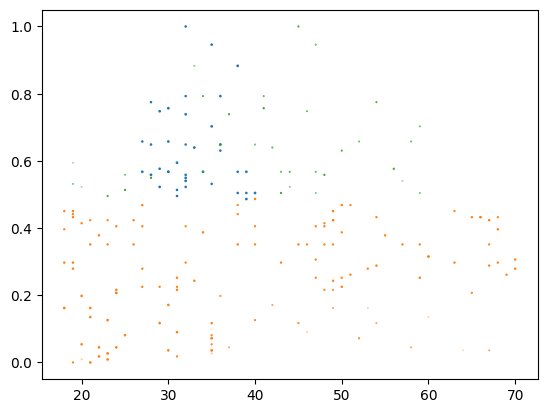

In [68]:
import matplotlib.pyplot as plt 
plt.scatter(df0["Age"], df0["Annual Income (k$)"], df0["Spending Score (1-100)"])
plt.scatter(df1["Age"], df1["Annual Income (k$)"], df1["Spending Score (1-100)"])
plt.scatter(df2["Age"], df2["Annual Income (k$)"], df2["Spending Score (1-100)"])

In [69]:
model.inertia_

138129.11504701106

In [70]:
model.cluster_centers_

array([[ 0.44736842, 32.76315789, 85.21052632, 82.10526316],
       [ 0.40650407, 40.32520325, 44.15447154, 49.82926829],
       [ 0.51351351, 40.62162162, 85.64864865, 18.64864865]])

In [71]:
from scipy.cluster.hierarchy import linkage
import scipy.cluster.hierarchy as sch

In [72]:
z = linkage(x, method="complete", metric="euclidean")

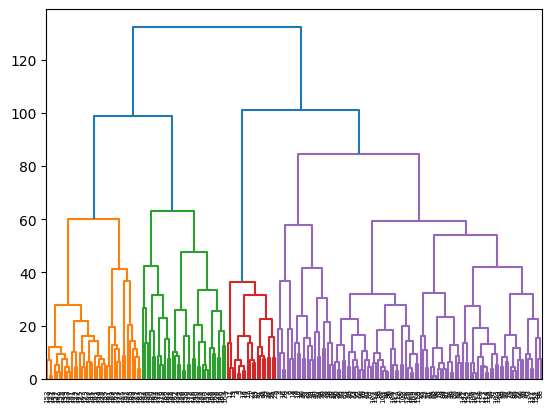

In [73]:
sch.dendrogram(z)
plt.show()

In [74]:
from sklearn.cluster import AgglomerativeClustering
ag = AgglomerativeClustering(n_clusters=6)

In [75]:
ag.fit(x)

,"n_clusters n_clusters: int or None, default=2The number of clusters to find. It must be ``None`` if``distance_threshold`` is not ``None``.",6
,"metric metric: str or callable, default=""euclidean""Metric used to compute the linkage. Can be ""euclidean"", ""l1"", ""l2"",""manhattan"", ""cosine"", or ""precomputed"". If linkage is ""ward"", only""euclidean"" is accepted. If ""precomputed"", a distance matrix is neededas input for the fit method. If connectivity is None, linkage is""single"" and affinity is not ""precomputed"" any valid pairwise distancemetric can be assigned.For an example of agglomerative clustering with different metrics, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_clustering_metrics.py`... versionadded:: 1.2",'euclidean'
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the output of the computation of the tree.By default, no caching is done. If a string is given, it is thepath to the caching directory.",None
,"connectivity connectivity: array-like, sparse matrix, or callable, default=NoneConnectivity matrix. Defines for each sample the neighboringsamples following a given structure of the data.This can be a connectivity matrix itself or a callable that transformsthe data into a connectivity matrix, such as derived from`kneighbors_graph`. Default is ``None``, i.e, thehierarchical clustering algorithm is unstructured.For an example of connectivity matrix using:class:`~sklearn.neighbors.kneighbors_graph`, see:ref:`sphx_glr_auto_examples_cluster_plot_ward_structured_vs_unstructured.py`.",None
,"compute_full_tree compute_full_tree: 'auto' or bool, default='auto'Stop early the construction of the tree at ``n_clusters``. This isuseful to decrease computation time if the number of clusters is notsmall compared to the number of samples. This option is useful onlywhen specifying a connectivity matrix. Note also that when varying thenumber of clusters and using caching, it may be advantageous to computethe full tree. It must be ``True`` if ``distance_threshold`` is not``None``. By default `compute_full_tree` is ""auto"", which is equivalentto `True` when `distance_threshold` is not `None` or that `n_clusters`is inferior to the maximum between 100 or `0.02 * n_samples`.Otherwise, ""auto"" is equivalent to `False`.",'auto'
,"linkage linkage: {'ward', 'complete', 'average', 'single'}, default='ward'Which linkage criterion to use. The linkage criterion determines whichdistance to use between sets of observation. The algorithm will mergethe pairs of cluster that minimize this criterion.- 'ward' minimizes the variance of the clusters being merged.- 'average' uses the average of the distances of each observation of the two sets.- 'complete' or 'maximum' linkage uses the maximum distances between all observations of the two sets.- 'single' uses the minimum of the distances between all observations of the two sets... versionadded:: 0.20 Added the 'single' optionFor examples comparing different `linkage` criteria, see:ref:`sphx_glr_auto_examples_cluster_plot_linkage_comparison.py`.",'ward'
,"distance_threshold distance_threshold: float, default=NoneThe linkage distance threshold at or above which clusters will not bemerged. If not ``None``, ``n_clusters`` must be ``None`` and``compute_full_tree`` must be ``True``... versionadded:: 0.21",None
,"compute_distances compute_distances: bool, default=FalseComputes distances between clusters even if `distance_threshold` is notused. This can be used to make dendrogram visualization, but introducesa computational and memory overhead... versionadded:: 0.24For an example of dendrogram visualization, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_dendrogram.py`.",False


In [76]:
df["labels"]=ag.labels_

In [77]:
df0 = df[df["labels"]==0]
df1 = df[df["labels"]==1]
df2 = df[df["labels"]==2]
df3 = df[df["labels"]==3]
df4 = df[df["labels"]==4]
df5 = df[df["labels"]==5]

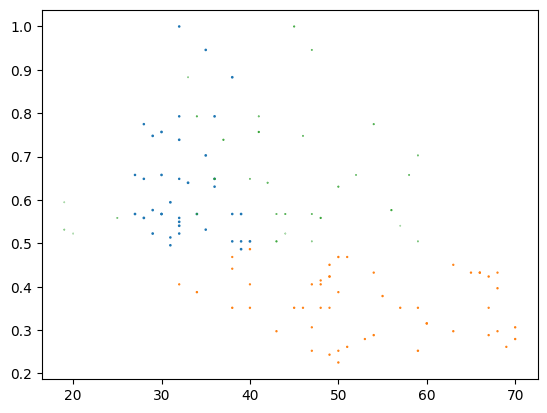

In [78]:
plt.scatter(df0["Age"], df0["Annual Income (k$)"], df0["Spending Score (1-100)"])
plt.scatter(df1["Age"], df1["Annual Income (k$)"], df1["Spending Score (1-100)"])
plt.scatter(df2["Age"], df2["Annual Income (k$)"], df2["Spending Score (1-100)"])